<a href="https://colab.research.google.com/github/CyberSnorlax/ETF-Markowitz-Portfolio-Optimization/blob/main/Alpha2_ROE_DE_next_month.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part 1: Data Collection and Feature Engineering


In [3]:
#%% [code]
import yfinance as yf
import pandas as pd
import numpy as np
import os
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
import joblib
import datetime

# File paths and date ranges
price_data_path = '/content/drive/MyDrive/Next-month/price_data.csv'
features_path = '/content/drive/MyDrive/Next-month/features_data.csv'
scaler_path = '/content/drive/MyDrive/Next-month/scaler.joblib'
sp500_index_path = '/content/drive/MyDrive/Next-month/sp500_index.csv'
# For saving scaled datasets (if needed)
X_train_scaled_path = '/content/drive/MyDrive/Next-month/X_train_scaled.joblib'
X_val_scaled_path = '/content/drive/MyDrive/Next-month/X_val_scaled.joblib'
X_test_scaled_path = '/content/drive/MyDrive/Next-month/X_test_scaled.joblib'
y_train_path = '/content/drive/MyDrive/Next-month/y_train.joblib'
y_val_path = '/content/drive/MyDrive/Next-month/y_val.joblib'
y_test_path = '/content/drive/MyDrive/Next-month/y_test.joblib'

# Define the periods for ML training
train_start = '2019-01-01'
train_end   = '2023-12-31'
val_start   = '2023-12-31'  # Overlap end/beginning can be adjusted as needed
val_end     = '2024-12-31'
test_start  = '2025-01-01'
test_end    = '2025-04-30'
data_start  = '2018-01-01'  # For technical indicator warm-up

# Function to fetch the list of S&P500 tickers from Wikipedia
def fetch_sp500_tickers():
    print("Fetching S&P500 tickers...")
    tickers = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]['Symbol'].tolist()
    # Adjust ticker symbols if needed (e.g. BRK.B -> BRK-B)
    tickers = [t.replace('BRK.B', 'BRK-B').replace('BF.B', 'BF-B') for t in tickers]
    return tickers

# Function to fetch historical price data for all tickers
def fetch_price_data(tickers):
    # Force fresh download to ensure latest data
    print("Fetching latest price data from yfinance...")
    data = yf.download(tickers, start=data_start, end=test_end, auto_adjust=True, threads=True)['Close']
    # Drop tickers with too many missing values
    data = data.dropna(axis=1, thresh=int(0.9 * len(data)))
    data.to_csv(price_data_path)
    print(f"Saved price data for {len(data.columns)} tickers to {price_data_path}")
    print(f"Price data date range: {data.index.min()} to {data.index.max()}")
    return data

# Function to fetch the S&P500 index (for regime detection or benchmark)
def fetch_sp500_index():
    # Force fresh download to ensure latest data
    print("Fetching latest S&P500 index data from yfinance...")
    sp500 = yf.download('^GSPC', start=data_start, end=test_end, auto_adjust=True)['Close']
    sp500.to_csv(sp500_index_path)
    print(f"Saved S&P500 index data to {sp500_index_path}")
    print(f"S&P500 index date range: {sp500.index.min()} to {sp500.index.max()}")
    return sp500

# Function to retrieve fundamental data (ROE and Debt/Equity) for a ticker
def get_fundamentals(ticker):
    try:
        t = yf.Ticker(ticker)
        info = t.info
        # ROE is often reported as a decimal (e.g., 0.20 for 20%)
        roe = info.get('returnOnEquity', None)
        # Debt-to-equity might be provided as a string or float (assume float)
        debt_to_equity = info.get('debtToEquity', None)
        return roe, debt_to_equity
    except Exception as e:
        print(f"Error fetching fundamentals for {ticker}: {e}")
        return None, None

# Function to calculate technical indicators
def calculate_indicators(close):
    sma20 = close.rolling(20).mean()
    sma50 = close.rolling(50).mean()
    sma200 = close.rolling(200).mean()
    sma_ratio = sma20 / sma50 - 1
    # Additional indicators
    delta = close.diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = -delta.where(delta < 0, 0).rolling(14).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    ema12 = close.ewm(span=12).mean()
    ema26 = close.ewm(span=26).mean()
    macd = ema12 - ema26
    signal = macd.ewm(span=9).mean()
    macd_hist = macd - signal
    volatility = close.pct_change().rolling(30).std() * np.sqrt(252)
    std20 = close.rolling(20).std()
    bb_width = (sma20 + 2 * std20 - (sma20 - 2 * std20)) / sma20

    df = pd.DataFrame({
        'sma_ratio': sma_ratio,
        'rsi': rsi,
        'macd_hist': macd_hist,
        'volatility': volatility,
        'bb_width': bb_width,
        'sma200': sma200
    })
    return df

# Function to calculate ARIMA-based features for stock data
def calculate_arima_features(close, periods=[5, 10, 21]):
    import warnings
    warnings.filterwarnings("ignore")

    arima_features = pd.DataFrame(index=close.index)

    log_close = np.log(close)
    log_returns = log_close.diff().dropna()

    try:
        model = ARIMA(log_returns, order=(1, 0, 1))
        model_fit = model.fit()

        for period in periods:
            forecast = model_fit.forecast(steps=period)
            cumulative_forecast = forecast.sum()
            current_log_price = log_close.iloc[-1]
            predicted_log_price = current_log_price + cumulative_forecast
            predicted_price = np.exp(predicted_log_price)
            current_price = close.iloc[-1]
            predicted_return = (predicted_price / current_price) - 1

            arima_features[f'arima_pred_{period}d'] = np.nan
            arima_features.iloc[-1, arima_features.columns.get_loc(f'arima_pred_{period}d')] = predicted_return
            arima_features[f'arima_pred_{period}d'] = arima_features[f'arima_pred_{period}d'].fillna(method='bfill')

        params = model_fit.params
        arima_features['arima_ar1'] = params.get('ar.L1', 0)
        arima_features['arima_ma1'] = params.get('ma.L1', 0)
        arima_features['arima_const'] = params.get('const', 0)
        arima_features['arima_aic'] = model_fit.aic
        arima_features['arima_volatility'] = log_returns.std() * np.sqrt(252)

    except Exception as e:
        print(f"ARIMA model error: {e}")
        for period in periods:
            arima_features[f'arima_pred_{period}d'] = 0
        arima_features['arima_ar1'] = 0
        arima_features['arima_ma1'] = 0
        arima_features['arima_const'] = 0
        arima_features['arima_aic'] = 0
        arima_features['arima_volatility'] = log_returns.std() * np.sqrt(252) if not log_returns.empty else 0

    return arima_features

def prepare_data(price_data, sp500_index, tickers):
    features_list = []

    skipped_tickers = {
        'insufficient_data': [],
        'missing_fundamentals': [],
        'insufficient_rows': [],
        'error': []
    }

    # For regime or market state
    regime = (sp500_index.rolling(200).mean() > sp500_index).astype(int)

    for ticker in tickers:
        print(f"Processing {ticker} ...")
        try:
            close = price_data[ticker].dropna()
            if len(close) < 252:
                skipped_tickers['insufficient_data'].append(ticker)
                print(f"Skipping {ticker}: insufficient data")
                continue

            # Compute technical indicators
            tech_df = calculate_indicators(close)

            # Compute ARIMA features
            arima_df = calculate_arima_features(close, periods=[5, 10, 21])

            # Merge technical and ARIMA features
            features_df = pd.concat([tech_df, arima_df], axis=1)
            features_df = features_df.loc[:,~features_df.columns.duplicated()]

            # Get fundamental data
            roe, debt_to_equity = get_fundamentals(ticker)
            if roe is None or debt_to_equity is None:
                skipped_tickers['missing_fundamentals'].append(ticker)
                print(f"Skipping {ticker}: missing fundamental data")
                continue

            features_df['roe'] = roe
            features_df['debt_to_equity'] = debt_to_equity

            # Compute a binary flag: is price above 200-day SMA?
            features_df['above_sma200'] = (close > features_df['sma200']).astype(int)

            # Fundamental Filters as additional features
            features_df['fund_long'] = ((close > features_df['sma200']) & (roe > 0.20) & (debt_to_equity < 1)).astype(int)
            features_df['fund_short'] = ((close < features_df['sma200']) & (roe < 0.10) & (debt_to_equity > 2)).astype(int)

            # Add ticker and date information
            features_df['ticker'] = ticker
            features_df['date'] = close.index

            # Drop rows with missing indicators
            feature_cols = list(features_df.columns.difference(['ticker', 'date']))
            features_df = features_df.dropna(subset=feature_cols)

            if len(features_df) < 50:
                skipped_tickers['insufficient_rows'].append(ticker)
                print(f"Skipping {ticker}: insufficient rows after cleaning")
                continue

            # Include a market regime feature
            features_df['regime'] = regime.reindex(features_df.index, method='ffill').fillna(0)

            features_list.append(features_df)
        except Exception as e:
            skipped_tickers['error'].append(ticker)
            print(f"Error processing {ticker}: {e}")

    if not features_list:
        raise ValueError("No valid feature data was generated.")

    all_features = pd.concat(features_list, ignore_index=True)
    all_features.to_csv(features_path, index=False)
    print(f"Saved features data to {features_path}")
    print(f"Features data date range: {all_features['date'].min()} to {all_features['date'].max()}")
    print(f"Processed a total of {len(features_list)} stocks with {len(all_features)} data points and {len(all_features.columns) - 2} features")
    print(f"Skipped {skipped_tickers}")

    return all_features

# --- Main execution ---
if __name__ == "__main__":
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/Next-month

    tickers = fetch_sp500_tickers()
    price_data = fetch_price_data(tickers)
    sp500_index = fetch_sp500_index()
    features_df = prepare_data(price_data, sp500_index, tickers)

Mounted at /content/drive
/content/drive/MyDrive/Next-month
Fetching S&P500 tickers...
Fetching latest price data from yfinance...


[*********************100%***********************]  503 of 503 completed


Saved price data for 483 tickers to /content/drive/MyDrive/Next-month/price_data.csv
Price data date range: 2018-01-02 00:00:00 to 2025-04-29 00:00:00
Fetching latest S&P500 index data from yfinance...


[*********************100%***********************]  1 of 1 completed


Saved S&P500 index data to /content/drive/MyDrive/Next-month/sp500_index.csv
S&P500 index date range: 2018-01-02 00:00:00 to 2025-04-29 00:00:00
Processing MMM ...
Processing AOS ...
Processing ABT ...
Processing ABBV ...
Skipping ABBV: missing fundamental data
Processing ACN ...
Processing ADBE ...
Processing AMD ...
Processing AES ...
Processing AFL ...
Processing A ...
Processing APD ...
Processing ABNB ...
Error processing ABNB: 'ABNB'
Processing AKAM ...
Processing ALB ...
Processing ARE ...
Processing ALGN ...
Processing ALLE ...
Processing LNT ...
Processing ALL ...
Processing GOOGL ...
Processing GOOG ...
Processing MO ...
Skipping MO: missing fundamental data
Processing AMZN ...
Processing AMCR ...
Processing AEE ...
Processing AEP ...
Processing AXP ...
Processing AIG ...
Processing AMT ...
Processing AWK ...
Processing AMP ...
Processing AME ...
Processing AMGN ...
Processing APH ...
Processing ADI ...
Processing ANSS ...
Processing AON ...
Processing APA ...
Processing APO 

Part 2: Model Training and Prediction Aggregation

In [9]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.losses import MeanSquaredError
from sklearn.preprocessing import StandardScaler
import joblib

# File paths
features_path = '/content/drive/MyDrive/Next-month/features_data.csv'
price_data_path = '/content/drive/MyDrive/Next-month/price_data.csv'
scaler_path = '/content/drive/MyDrive/Next-month/scaler.joblib'
lr_model_path = '/content/drive/MyDrive/Next-month/lr_model.joblib'
knn_model_path = '/content/drive/MyDrive/Next-month/knn_model.joblib'
lstm_model_path = '/content/drive/MyDrive/Next-month/lstm_model.h5'

# Check TensorFlow version
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")

# Load data
features_df = pd.read_csv(features_path)
features_df['date'] = pd.to_datetime(features_df['date'])
price_data = pd.read_csv(price_data_path, index_col='Date', parse_dates=True)

# Define periods
train_start, train_end = '2019-01-01', '2023-12-31'
val_start, val_end = '2024-01-01', '2024-12-31'
test_start, test_end = '2025-01-01', '2025-04-30'

# Split data
train_mask = (features_df['date'] >= pd.to_datetime(train_start)) & (features_df['date'] <= pd.to_datetime(train_end))
val_mask = (features_df['date'] >= pd.to_datetime(val_start)) & (features_df['date'] <= pd.to_datetime(val_end))
train_df = features_df[train_mask].copy()
val_df = features_df[val_mask].copy()

# Calculate forward-looking 21-day returns as target
historical_returns = []
for ticker in train_df['ticker'].unique():
    close = price_data[ticker].loc[train_start:val_end]
    ret = close.pct_change(21).shift(-21)  # 21-day return, aligned with current date
    ret_df = pd.DataFrame({'date': close.index, 'historical_return': ret})
    ret_df['ticker'] = ticker
    historical_returns.append(ret_df)

historical_returns_df = pd.concat(historical_returns)
historical_returns_df['date'] = pd.to_datetime(historical_returns_df['date'])

# Merge historical returns with features
train_df = train_df.merge(historical_returns_df, on=['ticker', 'date'], how='left')
val_df = val_df.merge(historical_returns_df, on=['ticker', 'date'], how='left')

# Drop rows with missing returns
train_df = train_df.dropna(subset=['historical_return'])
val_df = val_df.dropna(subset=['historical_return'])

# Prepare features and target
feature_cols = [col for col in train_df.columns if col not in ['ticker', 'date', 'historical_return']]
X_train = train_df[feature_cols].values
y_train = train_df['historical_return'].values
X_val = val_df[feature_cols].values
y_val = val_df['historical_return'].values

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Save scaler
joblib.dump(scaler, scaler_path)

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
joblib.dump(lr_model, lr_model_path)

# Train KNN Regressor
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
joblib.dump(knn_model, knn_model_path)

# Train LSTM
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_val_lstm = X_val_scaled.reshape((X_val_scaled.shape[0], 1, X_val_scaled.shape[1]))
lstm_model = Sequential([
    LSTM(50, input_shape=(1, X_train_scaled.shape[1])),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss=MeanSquaredError())
lstm_model.fit(X_train_lstm, y_train, validation_data=(X_val_lstm, y_val), epochs=10, batch_size=32, verbose=1)
lstm_model.save(lstm_model_path)

print("Models trained and saved.")

TensorFlow version: 2.18.0
Epoch 1/10
16432/16432 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - loss: 0.0098 - val_loss: 0.0070
Epoch 2/10
16432/16432 ━━━━━━━━━━━━━━━━━━━━ 34s 2ms/step - loss: 0.0093 - val_loss: 0.0070
Epoch 3/10
16432/16432 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - loss: 0.0090 - val_loss: 0.0071
Epoch 4/10
16432/16432 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - loss: 0.0089 - val_loss: 0.0071
Epoch 5/10
16432/16432 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - loss: 0.0088 - val_loss: 0.0070
Epoch 6/10
16432/16432 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - loss: 0.0087 - val_loss: 0.0074
Epoch 7/10
16432/16432 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step - loss: 0.0087 - val_loss: 0.0074
Epoch 8/10
16432/16432 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step - loss: 0.0086 - val_loss: 0.0074
Epoch 9/10
16432/16432 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - loss: 0.0086 - val_loss: 0.0074
Epoch 10/10
16432/16432 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - loss: 0.0086 - val_loss: 0.0073


Models trained and saved.


Part 3: Aggregate Predictions (Ensemble Method)

In [15]:
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import mse

# File paths
features_path = '/content/drive/MyDrive/Next-month/features_data.csv'
scaler_path = '/content/drive/MyDrive/Next-month/scaler.joblib'
lr_model_path = '/content/drive/MyDrive/Next-month/lr_model.joblib'
knn_model_path = '/content/drive/MyDrive/Next-month/knn_model.joblib'
lstm_model_path = '/content/drive/MyDrive/Next-month/lstm_model.h5'
predictions_path = '/content/drive/MyDrive/Next-month/predictions.csv'

def aggregate_predictions(features_df, scaler):
    # Load models
    lr_model = joblib.load(lr_model_path)
    knn_model = joblib.load(knn_model_path)
    lstm_model = load_model(lstm_model_path, custom_objects={'mse': mse})  # Pass mse to custom_objects

    # Prepare features
    feature_cols = [col for col in features_df.columns if col not in ['ticker', 'date']]
    X = features_df[feature_cols].values
    X_scaled = scaler.transform(X)

    # Make predictions
    lr_pred = lr_model.predict(X_scaled)
    knn_pred = knn_model.predict(X_scaled)
    X_lstm = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
    lstm_pred = lstm_model.predict(X_lstm, verbose=0).flatten()

    # Ensemble prediction (average)
    ensemble_pred = (lr_pred + knn_pred + lstm_pred) / 3

    # Create pred_df with required columns
    pred_df = features_df[['ticker', 'date', 'above_sma200', 'roe', 'debt_to_equity']].copy()
    pred_df['ensemble_pred'] = ensemble_pred

    pred_df.to_csv(predictions_path, index=False)
    print(f"Predictions saved to {predictions_path}")
    print(f"Predictions date range: {pred_df['date'].min()} to {pred_df['date'].max()}")

    return pred_df

# --- Usage ---
features_df = pd.read_csv(features_path)
features_df['date'] = pd.to_datetime(features_df['date'])
scaler = joblib.load(scaler_path)
pred_df = aggregate_predictions(features_df, scaler)

Predictions saved to /content/drive/MyDrive/Next-month/predictions.csv
Predictions date range: 2018-10-16 00:00:00 to 2025-04-29 00:00:00


Part 4: Portfolio Construction and Backtesting

Building portfolio selections...
Months available: <PeriodArray>
['2018-10', '2018-11', '2018-12', '2019-01', '2019-02', '2019-03', '2019-04',
 '2019-05', '2019-06', '2019-07', '2019-08', '2019-09', '2019-10', '2019-11',
 '2019-12', '2020-01', '2020-02', '2020-03', '2020-04', '2020-05', '2020-06',
 '2020-07', '2020-08', '2020-09', '2020-10', '2020-11', '2020-12', '2021-01',
 '2021-02', '2021-03', '2021-04', '2021-05', '2021-06', '2021-07', '2021-08',
 '2021-09', '2021-10', '2021-11', '2021-12', '2022-01', '2022-02', '2022-03',
 '2022-04', '2022-05', '2022-06', '2022-07', '2022-08', '2022-09', '2022-10',
 '2022-11', '2022-12', '2023-01', '2023-02', '2023-03', '2023-04', '2023-05',
 '2023-06', '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12',
 '2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07',
 '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02',
 '2025-03', '2025-04']
Length: 79, dtype: period[M]
Month 2018-10: 2 long, 62

[*********************100%***********************]  1 of 1 completed

Month 2023-11: 3 long, 62 short candidates
Month 2023-11 - Long tickers (up to 20): ['ERIE', 'ANET', 'TPL']
Month 2023-11 - Short tickers (up to 20): ['CNP', 'MOS', 'PARA', 'CAG', 'OXY', 'ADM', 'PNW', 'D', 'ZBH', 'KMX', 'ED', 'KHC', 'FE', 'AVB', 'KDP', 'BIIB', 'TSN', 'BEN', 'HRL', 'APD']
Month 2023-12: 2 long, 32 short candidates
Month 2023-12 - Long tickers (up to 20): ['ANET', 'ERIE']
Month 2023-12 - Short tickers (up to 20): ['CTRA', 'WBA', 'ADM', 'ALB', 'MOS', 'EL', 'BIIB', 'OXY', 'WBD', 'CPT', 'JCI', 'D', 'MAA', 'EVRG', 'ZBH', 'NEE', 'RVTY', 'CZR', 'BDX', 'PARA']
Month 2024-01: 2 long, 44 short candidates
Month 2024-01 - Long tickers (up to 20): ['ANET', 'ERIE']
Month 2024-01 - Short tickers (up to 20): ['ALB', 'EL', 'RVTY', 'HRL', 'DOC', 'PARA', 'CTRA', 'D', 'MOS', 'O', 'EQT', 'FE', 'PCG', 'JCI', 'EVRG', 'TECH', 'APD', 'OXY', 'TAP', 'PNW']
Month 2024-02: 2 long, 37 short candidates
Month 2024-02 - Long tickers (up to 20): ['ERIE', 'ANET']
Month 2024-02 - Short tickers (up to 20):

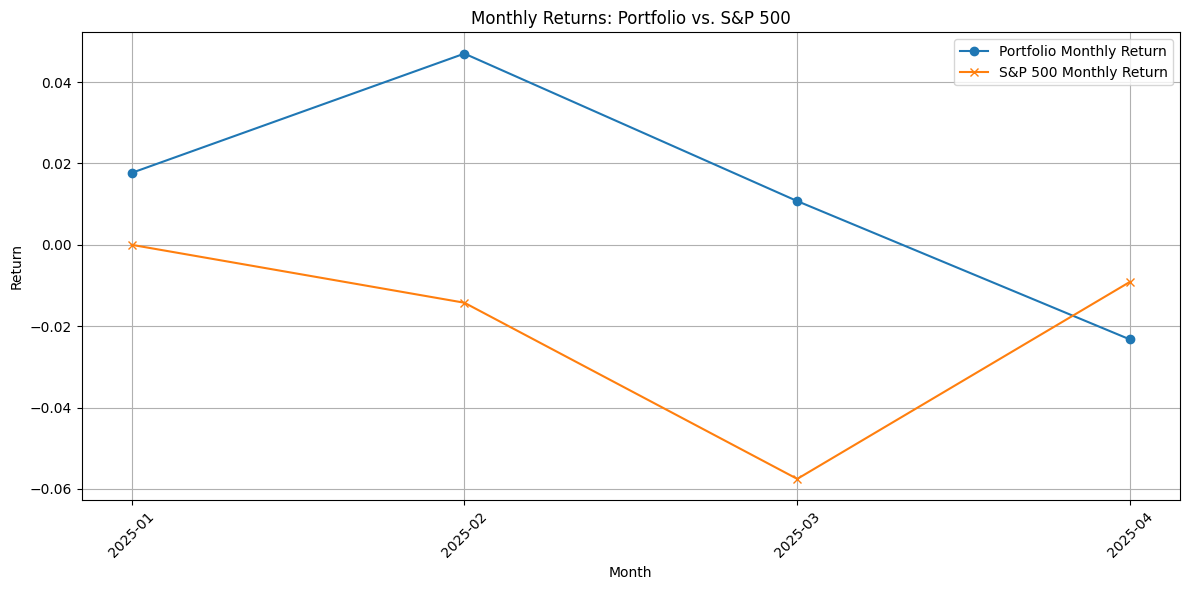

In [29]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Define the test period
test_start = '2025-01-01'
test_end = '2025-04-30'

def construct_portfolio(pred_df, n_long=20, n_short=20):
    """Build a monthly long-short portfolio, print up to 20 unique tickers, and save results."""
    print("Building portfolio selections...")
    pred_df['date'] = pd.to_datetime(pred_df['date'])
    pred_df['year_month'] = pred_df['date'].dt.to_period('M')

    print("Months available:", pred_df['year_month'].unique())

    portfolios = []
    for period, group in pred_df.groupby('year_month'):
        # Deduplicate tickers within the month, keeping the most recent row
        group = group.sort_values('date', ascending=False).drop_duplicates(subset='ticker', keep='first')

        # Apply fundamental filters
        long_candidates = group[(group['above_sma200'] == 1) & (group['roe'] > 0.20) & (group['debt_to_equity'] < 1)]
        short_candidates = group[(group['above_sma200'] == 0) & (group['roe'] < 0.10) & (group['debt_to_equity'] > 2)]

        # Sort by ensemble_pred
        long_sorted = long_candidates.sort_values('ensemble_pred', ascending=False)
        short_sorted = short_candidates.sort_values('ensemble_pred', ascending=True)

        # Count unique candidates
        long_count = len(long_sorted)
        short_count = len(short_sorted)
        print(f"Month {period}: {long_count} long, {short_count} short candidates")

        # Print up to 20 unique tickers
        long_tickers = long_sorted['ticker'].head(n_long).tolist()
        short_tickers = short_sorted['ticker'].head(n_short).tolist()
        print(f"Month {period} - Long tickers (up to {n_long}):", long_tickers)
        print(f"Month {period} - Short tickers (up to {n_short}):", short_tickers)

        # Build portfolio with available candidates
        long_stocks = long_sorted.head(min(n_long, long_count))[['ticker', 'date', 'ensemble_pred']]
        short_stocks = short_sorted.head(min(n_short, short_count))[['ticker', 'date', 'ensemble_pred']]

        if not long_stocks.empty and not short_stocks.empty:
            long_stocks['position'] = 'long'
            short_stocks['position'] = 'short'
            month_portfolio = pd.concat([long_stocks, short_stocks])
            month_portfolio['year_month'] = period
            portfolios.append(month_portfolio)
        else:
            print(f"Month {period}: Skipping - not enough long or short stocks.")

    if not portfolios:
        raise ValueError("No portfolios were created.")
    portfolio_df = pd.concat(portfolios, ignore_index=True)
    portfolio_df.to_csv('/content/drive/MyDrive/Next-month/portfolio_selections.csv', index=False)
    print("Saved portfolio to portfolio_selections.csv")
    return portfolio_df

def backtest_portfolio(price_data, portfolio_df):
    """Backtest the portfolio, print monthly returns, and plot them against S&P 500."""
    print("Backtesting portfolio (Modified)...")
    # Ensure price_data index is datetime
    price_data.index = pd.to_datetime(price_data.index)
    price_data_test = price_data.loc[test_start:test_end]

    # Debug: Check price_data date range
    print("Price data date range:", price_data_test.index.min(), "to", price_data_test.index.max())

    portfolio_df['date'] = pd.to_datetime(portfolio_df['date'])
    portfolio_df = portfolio_df[(portfolio_df['date'] >= test_start) & (portfolio_df['date'] <= test_end)]
    portfolio_df['year_month'] = portfolio_df['date'].dt.to_period('M')

    daily_returns = price_data_test.pct_change().dropna()
    monthly_returns = []

    # Create a full list of months in the test period
    all_months = pd.period_range(start=test_start, end=test_end, freq='M')
    print("Expected months:", all_months)

    for period in all_months:
        period_str = str(period)
        group = portfolio_df[portfolio_df['year_month'] == period]
        if group.empty:
            print(f"No portfolio data for {period_str}. Recording zero return.")
            monthly_returns.append({
                'year_month': period_str,
                'long_return': 0.0,
                'short_return': 0.0,
                'portfolio_return': 0.0
            })
            continue

        month_start = group['date'].min()
        month_end = month_start + pd.offsets.MonthEnd(0)
        if month_end > pd.to_datetime(test_end):
            month_end = pd.to_datetime(test_end)

        month_ret = daily_returns.loc[month_start:month_end]
        if month_ret.empty:
            print(f"No price data for {period_str}. Recording zero return.")
            monthly_returns.append({
                'year_month': period_str,
                'long_return': 0.0,
                'short_return': 0.0,
                'portfolio_return': 0.0
            })
            continue

        # Get unique long and short tickers for the month
        long_tickers = group[group['position'] == 'long']['ticker'].unique().tolist()
        short_tickers = group[group['position'] == 'short']['ticker'].unique().tolist()

        # Print positions for this month
        print(f"\n{period_str} Positions:")
        print("Long:", long_tickers)
        print("Short:", short_tickers)

        # Calculate average returns for long and short sides
        long_returns = month_ret[long_tickers].mean(axis=1) if long_tickers else pd.Series()
        short_returns = month_ret[short_tickers].mean(axis=1) if short_tickers else pd.Series()
        if long_returns.empty or short_returns.empty:
            print(f"Skipping {period_str}: insufficient returns data. Recording zero return.")
            monthly_returns.append({
                'year_month': period_str,
                'long_return': 0.0,
                'short_return': 0.0,
                'portfolio_return': 0.0
            })
            continue

        long_cum_return = (1 + long_returns).cumprod().iloc[-1] - 1
        short_cum_return = (1 + short_returns).cumprod().iloc[-1] - 1
        portfolio_return = (long_cum_return - short_cum_return)

        print(f"{period_str} Monthly Return: {portfolio_return:.4f}")
        monthly_returns.append({
            'year_month': period_str,
            'long_return': long_cum_return,
            'short_return': short_cum_return,
            'portfolio_return': portfolio_return
        })

    returns_df = pd.DataFrame(monthly_returns)

    # Fetch S&P 500 monthly returns for the same period
    sp500 = yf.download('^GSPC', start=test_start, end=test_end, auto_adjust=True)['Close']
    sp500_monthly = sp500.resample('M').last().pct_change().dropna()
    sp500_monthly.index = sp500_monthly.index.to_period('M')

    # Align the two datasets
    sp500_df = sp500_monthly.reset_index()
    sp500_df.columns = ['year_month', 'sp500_return']
    sp500_df['year_month'] = sp500_df['year_month'].astype(str)

    # Merge on year_month to ensure alignment
    merged_df = pd.DataFrame({'year_month': [str(m) for m in all_months]})
    merged_df = merged_df.merge(returns_df, on='year_month', how='left').merge(sp500_df, on='year_month', how='left')
    merged_df['portfolio_return'] = merged_df['portfolio_return'].fillna(0.0)
    merged_df['sp500_return'] = merged_df['sp500_return'].fillna(0.0)

    # Save returns
    merged_df.to_csv('/content/drive/MyDrive/Next-month/portfolio_returns.csv', index=False)
    print("Saved portfolio returns to portfolio_returns.csv")

    # Plot portfolio vs. S&P 500 monthly returns
    plt.figure(figsize=(12, 6))
    plt.plot(merged_df['year_month'], merged_df['portfolio_return'], marker='o', label='Portfolio Monthly Return')
    plt.plot(merged_df['year_month'], merged_df['sp500_return'], marker='x', label='S&P 500 Monthly Return')
    plt.title('Monthly Returns: Portfolio vs. S&P 500')
    plt.xlabel('Month')
    plt.ylabel('Return')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    return merged_df

# --- Usage ---
portfolio_df_mod = construct_portfolio(pred_df, n_long=20, n_short=20)
returns_df_mod = backtest_portfolio(price_data, portfolio_df_mod)

Part 5: Predict Next Month's Portfolio

In [31]:
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import load_model
import yfinance as yf

# File paths
features_path = '/content/drive/MyDrive/Next-month/features_data.csv'
scaler_path = '/content/drive/MyDrive/Next-month/scaler.joblib'
price_data_path = '/content/drive/MyDrive/Next-month/price_data.csv'
sp500_index_path = '/content/drive/MyDrive/Next-month/sp500_index.csv'

def predict_portfolio(features_df, scaler, target_year=None, target_month=None, lookback_days=60):
    """Predict next month's portfolio with up to 20 long and 20 short tickers."""
    # Set target date to next month if not specified
    if target_year is None or target_month is None:
        current_date = datetime.now()
        next_month = current_date.replace(day=1) + timedelta(days=32)  # Move to next month
        target_year = next_month.year if target_year is None else target_year
        target_month = next_month.month if target_month is None else target_month

    target_date = pd.to_datetime(f"{target_year}-{target_month:02d}-01")
    print(f"Predicting portfolio for {target_date.strftime('%B %Y')}")

    # Filter recent data
    features_df['date'] = pd.to_datetime(features_df['date'])
    latest_date = features_df['date'].max()
    recent_df = features_df[features_df['date'] >= (latest_date - timedelta(days=lookback_days))]

    # Get unique tickers
    tickers = recent_df['ticker'].unique().tolist()
    print(f"Found {len(tickers)} tickers with recent data")

    # Define feature columns to match training
    base_cols = ['sma_ratio', 'rsi', 'macd_hist', 'volatility', 'bb_width', 'sma200',  # Added sma200
                 'roe', 'debt_to_equity', 'above_sma200', 'fund_long', 'fund_short', 'regime']
    arima_cols = ['arima_pred_5d', 'arima_pred_10d', 'arima_pred_21d', 'arima_ar1', 'arima_ma1',
                  'arima_const', 'arima_aic', 'arima_volatility']
    X_cols = base_cols + arima_cols  # Total: 12 base + 8 ARIMA = 20 features

    # Collect features for prediction
    features_list = []
    valid_tickers = []
    for ticker in tickers:
        ticker_data = recent_df[recent_df['ticker'] == ticker]
        if len(ticker_data) < 10:  # Skip tickers with insufficient data
            continue

        # Get most recent data point
        latest_row = ticker_data.sort_values('date', ascending=False).iloc[0]
        if not all(col in latest_row for col in X_cols):
            continue

        roe = float(latest_row['roe'])
        debt_equity = float(latest_row['debt_to_equity'])
        above_sma200 = int(latest_row['above_sma200'])

        # Filter for long or short candidates
        is_long = (above_sma200 == 1 and roe > 0.20 and debt_equity < 1)
        is_short = (above_sma200 == 0 and roe < 0.10 and debt_equity > 2)
        if is_long or is_short:
            features = [latest_row[col] for col in X_cols]
            features_list.append(features)
            valid_tickers.append(ticker)

    if not features_list:
        print(f"No valid tickers found for {target_date.strftime('%B %Y')}")
        return None

    # Make predictions
    X = np.array(features_list)
    X_scaled = scaler.transform(X)

    # Load models
    lr = joblib.load('/content/drive/MyDrive/Next-month/lr_model.joblib')
    knn = joblib.load('/content/drive/MyDrive/Next-month/knn_model.joblib')
    lstm = load_model('/content/drive/MyDrive/Next-month/lstm_model.h5')

    # Predict with each model
    lr_pred = lr.predict(X_scaled)
    knn_pred = knn.predict(X_scaled)
    X_lstm = X_scaled.reshape(-1, 1, X_scaled.shape[1])
    lstm_pred = lstm.predict(X_lstm, verbose=0).flatten()

    # Combine predictions
    scores = (lr_pred + knn_pred + lstm_pred) / 3
    pred_df = pd.DataFrame({'ticker': valid_tickers, 'score': scores})

    # Select up to 20 long and 20 short tickers
    longs = pred_df.sort_values('score', ascending=False).head(20)
    shorts = pred_df.sort_values('score', ascending=True).head(20)

    # Create portfolio
    longs['position'] = 'LONG'
    shorts['position'] = 'SHORT'
    portfolio = pd.concat([longs, shorts])
    portfolio['target_date'] = target_date

    # Save portfolio
    file_name = f"{target_date.strftime('%Y%m')}_portfolio.csv"
    portfolio.to_csv(file_name, index=False)
    print(f"Saved portfolio to {file_name}")
    return portfolio

def update_data_if_needed(features_df):
    """Update data if older than 7 days."""
    print("Checking if data needs updating...")
    price_data = pd.read_csv(price_data_path, index_col='Date', parse_dates=True)
    sp500_index = pd.read_csv(sp500_index_path, index_col='Date', parse_dates=True)

    latest_date = price_data.index.max()
    current_date = datetime.now()
    if (current_date - latest_date).days > 7:
        print(f"Data is {(current_date - latest_date).days} days old. Updating...")
        tickers = features_df['ticker'].unique().tolist()

        # Download new data
        new_prices = yf.download(tickers, start=latest_date, end=current_date + timedelta(days=1),
                                 auto_adjust=True, threads=True)['Close']
        new_sp500 = yf.download('^GSPC', start=latest_date, end=current_date + timedelta(days=1),
                                auto_adjust=True)['Close']

        # Merge and remove duplicates
        price_data = pd.concat([price_data, new_prices]).drop_duplicates(keep='last')
        sp500_index = pd.concat([sp500_index, new_sp500]).drop_duplicates(keep='last')

        # Save updated data
        price_data.to_csv('/content/drive/MyDrive/Next-month/updated_price_data.csv')
        sp500_index.to_csv('/content/drive/MyDrive/Next-month/updated_sp500_index.csv')

        # Update features
        return prepare_data(price_data, sp500_index, tickers)
    print("Data is recent. Using existing features.")
    return features_df

def print_portfolio_summary(portfolio):
    """Print the portfolio summary."""
    if portfolio is None or portfolio.empty:
        print("No portfolio available.")
        return

    target_date = portfolio['target_date'].iloc[0]
    print(f"\n=== PORTFOLIO FOR {target_date.strftime('%B %Y').upper()} ===")

    print("\nLONG POSITIONS:")
    for _, row in portfolio[portfolio['position'] == 'LONG'].iterrows():
        print(f"{row['ticker']} (score: {row['score']:.2f})")

    print("\nSHORT POSITIONS:")
    for _, row in portfolio[portfolio['position'] == 'SHORT'].iterrows():
        print(f"{row['ticker']} (score: {row['score']:.2f})")

# Main execution
if __name__ == "__main__":
    features_df = pd.read_csv(features_path)
    scaler = joblib.load(scaler_path)
    features_df = update_data_if_needed(features_df)
    portfolio = predict_portfolio(features_df, scaler, target_year=2025, target_month=5)
    print_portfolio_summary(portfolio)

Checking if data needs updating...
Data is recent. Using existing features.
Predicting portfolio for May 2025
Found 418 tickers with recent data


Saved portfolio to 202505_portfolio.csv

=== PORTFOLIO FOR MAY 2025 ===

LONG POSITIONS:
CZR (score: 105.61)
AES (score: 73.49)
KMX (score: 65.77)
EL (score: 52.58)
BXP (score: 52.03)
GM (score: 50.48)
STZ (score: 47.41)
PCG (score: 46.83)
NEE (score: 44.44)
D (score: 44.28)
PRU (score: 43.27)
EQIX (score: 43.16)
UDR (score: 42.62)
FRT (score: 41.40)
WBD (score: 38.00)
DOC (score: 37.57)
SRE (score: 37.38)
BALL (score: 37.35)
APD (score: 37.24)
MCHP (score: 37.22)

SHORT POSITIONS:
TPL (score: 20.41)
AMD (score: 20.78)
IVZ (score: 22.21)
SWKS (score: 24.11)
TECH (score: 25.06)
ADI (score: 25.42)
TYL (score: 25.62)
BEN (score: 25.67)
ALB (score: 25.75)
XYL (score: 25.77)
MHK (score: 26.18)
EG (score: 26.71)
BIIB (score: 26.95)
DD (score: 27.08)
WDAY (score: 27.15)
VLO (score: 27.23)
NUE (score: 27.29)
EMR (score: 27.30)
NWSA (score: 27.38)
COO (score: 27.63)


Part 6: Performance Evaluation and Graphing

Evaluating portfolio performance...


[*********************100%***********************]  1 of 1 completed

Saved performance metrics to portfolio_performance.csv

Portfolio Performance Summary:
Total Return: 0.1402
Annualized Return: 0.4822
Annualized Volatility: 0.1936
Sharpe Ratio: 2.3880
Maximum Drawdown: -0.0183



Benchmark (S&P 500) Performance Summary:
Total Return: -0.0794
Annualized Return: -0.2818
Annualized Volatility: 0.0922
Sharpe Ratio: -3.2735
Maximum Drawdown: -0.0661

Strategy Outperformance vs. Benchmark:
Total Return: 0.2196 (better)
Annualized Return: 0.7640 (better)
Annualized Volatility: 0.1014 (worse)
Sharpe Ratio: 5.6614 (better)
Maximum Drawdown: 0.0478 (worse)


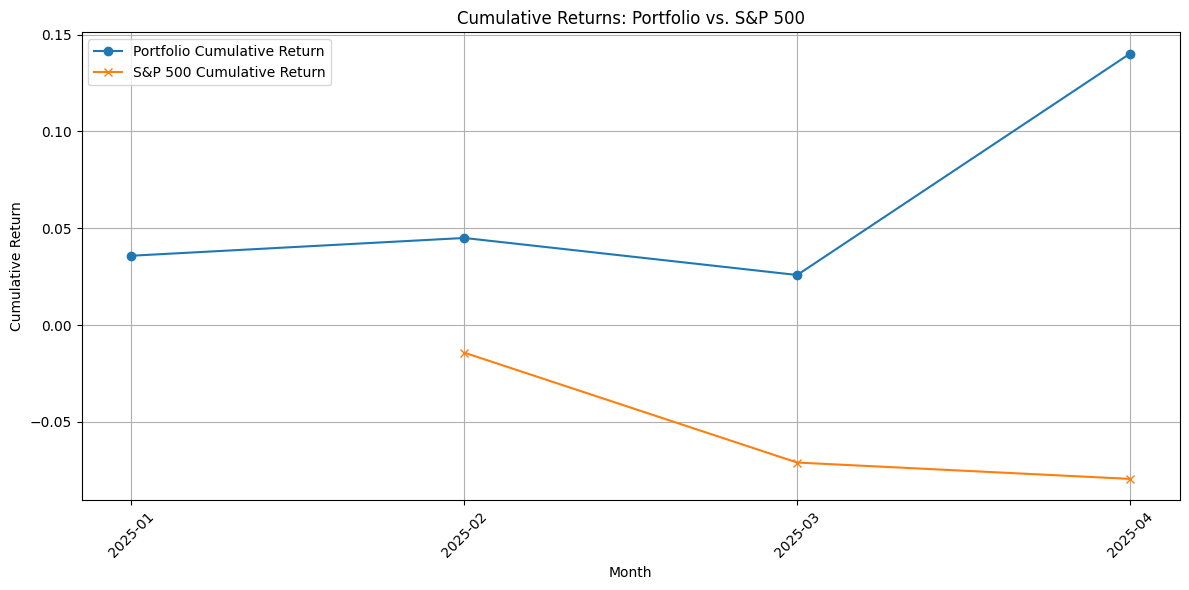

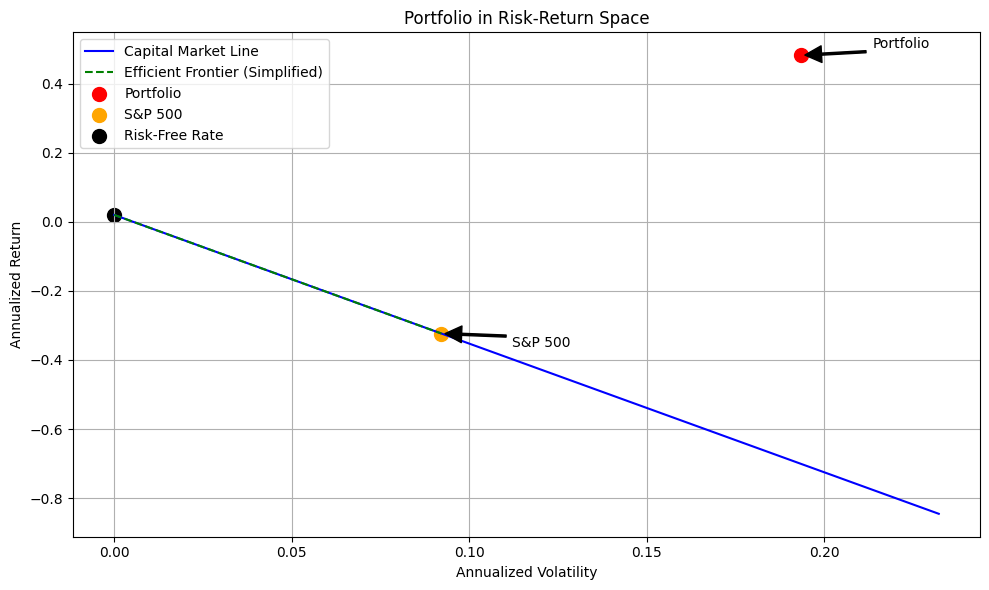

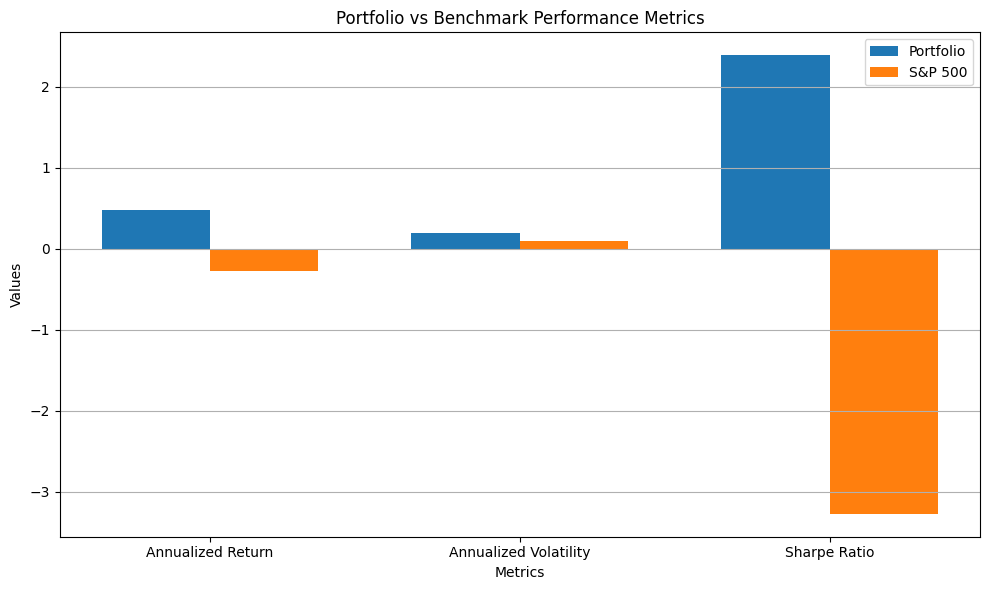

In [28]:
def evaluate_performance(returns_df, test_start, test_end, risk_free_rate=0.02):
    print("Evaluating portfolio performance...")
    returns_df['year_month'] = pd.to_datetime(returns_df['year_month'])
    returns_df = returns_df.sort_values('year_month')

    # Compute cumulative returns for portfolio
    returns_df['cumulative_return'] = (1 + returns_df['portfolio_return']).cumprod() - 1

    n_months = len(returns_df)
    total_return = returns_df['cumulative_return'].iloc[-1] if n_months > 0 else 0
    annualized_return = ((1 + total_return) ** (12 / n_months)) - 1 if n_months > 0 else 0
    monthly_vol = returns_df['portfolio_return'].std()
    annualized_vol = monthly_vol * np.sqrt(12) if monthly_vol is not None else 0
    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_vol if annualized_vol != 0 else 0

    # Maximum drawdown calculation
    cumulative = (1 + returns_df['portfolio_return']).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    max_drawdown = drawdown.min()

    performance_metrics = {
        'Total Return': total_return,
        'Annualized Return': annualized_return,
        'Annualized Volatility': annualized_vol,
        'Sharpe Ratio': sharpe_ratio,
        'Maximum Drawdown': max_drawdown
    }

    perf_df = pd.DataFrame([performance_metrics])
    perf_df.to_csv('portfolio_performance.csv', index=False)
    print("Saved performance metrics to portfolio_performance.csv")

    print("\nPortfolio Performance Summary:")
    for key, value in performance_metrics.items():
        print(f"{key}: {value:.4f}")

    # --- Fetch and calculate S&P 500 performance ---
    # Fetch S&P 500 data for the test period
    sp500 = yf.download('^GSPC', start=test_start, end=test_end, auto_adjust=True)['Close']
    # Get month-end close prices
    sp500_monthly_close = sp500.resample('ME').last()
    # Calculate month-over-month returns
    sp500_monthly_returns = sp500_monthly_close.pct_change().dropna()
    # Compute cumulative returns from these monthly returns
    sp500_monthly_cum = (1 + sp500_monthly_returns).cumprod() - 1

    # Calculate benchmark performance metrics
    benchmark_n_months = len(sp500_monthly_returns)
    benchmark_total_return = float(sp500_monthly_cum.iloc[-1]) if benchmark_n_months > 0 else 0
    benchmark_annualized_return = ((1 + benchmark_total_return) ** (12 / benchmark_n_months)) - 1 if benchmark_n_months > 0 else 0
    benchmark_monthly_vol = float(sp500_monthly_returns.std())
    benchmark_annualized_vol = benchmark_monthly_vol * np.sqrt(12) if benchmark_monthly_vol is not None else 0
    benchmark_sharpe_ratio = (benchmark_annualized_return - risk_free_rate) / benchmark_annualized_vol if benchmark_annualized_vol != 0 else 0

    # Benchmark Maximum drawdown calculation
    benchmark_cumulative = (1 + sp500_monthly_returns).cumprod()
    benchmark_rolling_max = benchmark_cumulative.cummax()
    benchmark_drawdown = (benchmark_cumulative - benchmark_rolling_max) / benchmark_rolling_max
    benchmark_max_drawdown = float(benchmark_drawdown.min())

    benchmark_metrics = {
        'Total Return': benchmark_total_return,
        'Annualized Return': benchmark_annualized_return,
        'Annualized Volatility': benchmark_annualized_vol,
        'Sharpe Ratio': benchmark_sharpe_ratio,
        'Maximum Drawdown': benchmark_max_drawdown
    }

    # Save benchmark metrics
    benchmark_df = pd.DataFrame([benchmark_metrics])
    benchmark_df.to_csv('benchmark_performance.csv', index=False)

    print("\nBenchmark (S&P 500) Performance Summary:")
    for key, value in benchmark_metrics.items():
        print(f"{key}: {value:.4f}")

    # Calculate outperformance metrics
    outperformance = {
        'Total Return': total_return - benchmark_total_return,
        'Annualized Return': annualized_return - benchmark_annualized_return,
        'Annualized Volatility': annualized_vol - benchmark_annualized_vol,
        'Sharpe Ratio': sharpe_ratio - benchmark_sharpe_ratio,
        'Maximum Drawdown': max_drawdown - benchmark_max_drawdown
    }

    print("\nStrategy Outperformance vs. Benchmark:")
    for key, value in outperformance.items():
        print(f"{key}: {value:.4f}" + (" (better)" if (key != 'Annualized Volatility' and key != 'Maximum Drawdown' and value > 0) or
                                        ((key == 'Annualized Volatility' or key == 'Maximum Drawdown') and value < 0) else " (worse)"))

    # Plot cumulative returns vs. S&P 500
    returns_df_plot = returns_df.copy()
    date_strings = returns_df_plot['year_month'].dt.strftime('%Y-%m')
    sp500_date_strings = sp500_monthly_cum.index.strftime('%Y-%m')

    plt.figure(figsize=(12,6))
    plt.plot(date_strings, returns_df_plot['cumulative_return'], marker='o', label='Portfolio Cumulative Return')
    plt.plot(sp500_date_strings, sp500_monthly_cum.values, marker='x', label='S&P 500 Cumulative Return')

    plt.title('Cumulative Returns: Portfolio vs. S&P 500')
    plt.xlabel('Month')
    plt.ylabel('Cumulative Return')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig('cumulative_returns_comparison.png')
    plt.show()

    # Compute Capital Market Line (CML) and a simplified Efficient Frontier
    # Use the monthly returns from the S&P 500
    market_return = float(sp500_monthly_returns.mean() * 12)
    market_vol = float(sp500_monthly_returns.std() * np.sqrt(12))
    cml_slope = (market_return - risk_free_rate) / market_vol if market_vol != 0 else 0
    cml_vols = np.linspace(0, max(annualized_vol, market_vol) * 1.2, 100)
    cml_returns = risk_free_rate + cml_slope * cml_vols

    eff_vols = np.linspace(0, market_vol, 100)
    eff_returns = risk_free_rate + (market_return - risk_free_rate) * (eff_vols / market_vol)

    plt.figure(figsize=(10,6))
    plt.plot(cml_vols, cml_returns, label='Capital Market Line', color='blue')
    plt.plot(eff_vols, eff_returns, label='Efficient Frontier (Simplified)', color='green', linestyle='--')
    plt.scatter([annualized_vol], [annualized_return], color='red', s=100, label='Portfolio')
    plt.scatter([market_vol], [market_return], color='orange', s=100, label='S&P 500')
    plt.scatter([0], [risk_free_rate], color='black', s=100, label='Risk-Free Rate')

    # Add annotations
    plt.annotate('Portfolio', xy=(annualized_vol, annualized_return),
                 xytext=(annualized_vol+0.02, annualized_return+0.02),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5))
    plt.annotate('S&P 500', xy=(market_vol, market_return),
                 xytext=(market_vol+0.02, market_return-0.04),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5))

    plt.title('Portfolio in Risk-Return Space')
    plt.xlabel('Annualized Volatility')
    plt.ylabel('Annualized Return')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig('risk_return_analysis.png')
    plt.show()

    # Add comparison bar chart
    metrics_to_compare = ['Annualized Return', 'Annualized Volatility', 'Sharpe Ratio']
    portfolio_values = [performance_metrics[m] for m in metrics_to_compare]
    benchmark_values = [benchmark_metrics[m] for m in metrics_to_compare]

    plt.figure(figsize=(10, 6))
    x = np.arange(len(metrics_to_compare))
    width = 0.35

    plt.bar(x - width/2, portfolio_values, width, label='Portfolio')
    plt.bar(x + width/2, benchmark_values, width, label='S&P 500')

    plt.xlabel('Metrics')
    plt.ylabel('Values')
    plt.title('Portfolio vs Benchmark Performance Metrics')
    plt.xticks(x, metrics_to_compare)
    plt.legend()
    plt.grid(axis='y')
    plt.tight_layout()
    plt.savefig('performance_comparison.png')
    plt.show()

    return returns_df, performance_metrics, benchmark_metrics

# --- Usage in Step 5 ---
returns_df_final, performance_metrics_final, benchmark_metrics_final = evaluate_performance(returns_df_mod, test_start, test_end)